In [1]:
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import ImageFolder
from torchvision import transforms

import torch
import torch.nn as nn
from tqdm import tqdm
import torch.optim as optim

import sys
sys.path.append("/kaggle/input/dependenciesv2/pytorch/default/1")

from dcgan import Generator, Discriminator, weights_init
from pilae_gpu import PILAE

DATASET_DIR = r"/kaggle/input/swedish-leaf-dataset/Swedish/Train"

transform = transforms.Compose([
    transforms.Resize(64),
    transforms.CenterCrop(64),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

full_dataset = ImageFolder(DATASET_DIR, transform=transform)

train_size = int(0.7* len(full_dataset))
test_size  = len(full_dataset) - train_size

train_dataset, test_dataset = random_split(
    full_dataset, [train_size, test_size]
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)




In [2]:
from collections import Counter

train_labels = []

for _, labels in train_loader:
    train_labels.extend(labels.tolist())

class_counts = Counter(train_labels)
print("Real class counts:", class_counts)


Real class counts: Counter({11: 59, 6: 57, 7: 55, 0: 54, 14: 54, 10: 54, 1: 54, 5: 53, 3: 52, 8: 52, 13: 50, 12: 49, 9: 49, 4: 48, 2: 47})


In [3]:
train_size = int(0.8 * len(full_dataset))
test_size  = len(full_dataset) - train_size

train_dataset, test_dataset = random_split(
    full_dataset, [train_size, test_size]
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)


In [4]:
dataset = ImageFolder(DATASET_DIR, transform=transform)
NUM_CLASSES = len(dataset.classes)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [5]:
nz  = 100    
ngf = 64
ndf = 64
nc  = 3

EPOCHS = 50
lr = 0.0002
beta1 = 0.5

netG = Generator(nz, ngf, nc, n_classes=NUM_CLASSES).to(device)
netD = Discriminator(nc, ndf, n_classes=NUM_CLASSES).to(device)

netG.apply(weights_init)
netD.apply(weights_init)

criterion = nn.BCELoss()

optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))


In [6]:
def extract_features(loader):
    X, y = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs   = imgs.to(device)
            labels = labels.to(device)
            feats = netD.extract_features(imgs, labels)
            X.append(feats.cpu())
            y.append(labels.cpu())
    return torch.cat(X), torch.cat(y)

In [7]:
X_train, y_train = extract_features(train_loader)
X_test,  y_test  = extract_features(test_loader)

print('Train features:', X_train.shape)
print('Test features :', X_test.shape)


Train features: torch.Size([900, 8192])
Test features : torch.Size([225, 8192])


In [8]:
from sklearn.preprocessing import OneHotEncoder

# X_train: (N, 8192) DCGAN features
# y_train: (N,) integer labels

enc = OneHotEncoder(sparse_output=False)
Y_train_oh = enc.fit_transform(y_train.reshape(-1, 1))

pilae = PILAE(beta=0.4, reg=1e-2)
pilae.fit(X_train, Y_train_oh)

y_pred = pilae.predict(X_test)


PILAE-GPU fit: X=torch.Size([900, 8192]), Y=torch.Size([900, 15]), device=cuda
Computing SVD...
Using truncated rank p=900
Solving regularized normal equations...
PILAE-GPU training complete.


In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="weighted")
rec = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")


Accuracy : 0.0489
Precision: 0.0059
Recall   : 0.0489
F1-score : 0.0106


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Confusion Matrix:
 [[ 0  0  0  0  0  0  0  9 11  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  5  7  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  9 13  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  3  8  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  7  4  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  8 10  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  6  5  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  8  5  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  9  3  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  5  9  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  3 11  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  9 11  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  7 15  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  2  8  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  9  6  0  0  0  0  0  0]]


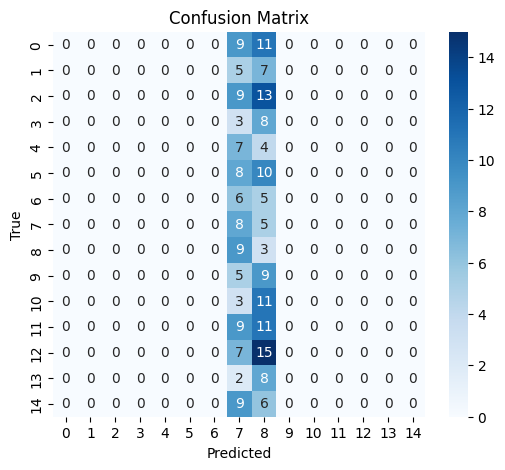

In [10]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()



In [11]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.00      0.00      0.00        20
           1       0.00      0.00      0.00        12
           2       0.00      0.00      0.00        22
           3       0.00      0.00      0.00        11
           4       0.00      0.00      0.00        11
           5       0.00      0.00      0.00        18
           6       0.00      0.00      0.00        11
           7       0.08      0.62      0.14        13
           8       0.02      0.25      0.04        12
           9       0.00      0.00      0.00        14
          10       0.00      0.00      0.00        14
          11       0.00      0.00      0.00        20
          12       0.00      0.00      0.00        22
          13       0.00      0.00      0.00        10
          14       0.00      0.00      0.00        15

    accuracy                           0.05       225
   macro avg       0.01      0.06      0.01       225
weighted avg       0.01   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
